In [ ]:
#!pip install -q torch torchvision tqdm torchview
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torchview

In [ ]:
import os
import torch
import pickle
import numpy as np
import torchvision
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm
from torchview import draw_graph
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [ ]:
#@title Setting global device property

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
# Define a more efficient ResNet model
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.GroupNorm(8, planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.GroupNorm(8, planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.GroupNorm(8, planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 32

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.GroupNorm(8, 32)

        self.layer1 = self._make_layer(block, 32, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 64, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 128, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 256, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def ResNet18Efficient():
    # return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
    return ResNet(BasicBlock, [4, 4, 3, 1], num_classes=10)
def get_device():
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print("Using device:", device)

In [ ]:
device = get_device()
model = ResNet18Efficient().to(device)
print("Total model parameters:", sum(p.numel() for p in model.parameters()))

Using device: cuda
Total model parameters: 2097450


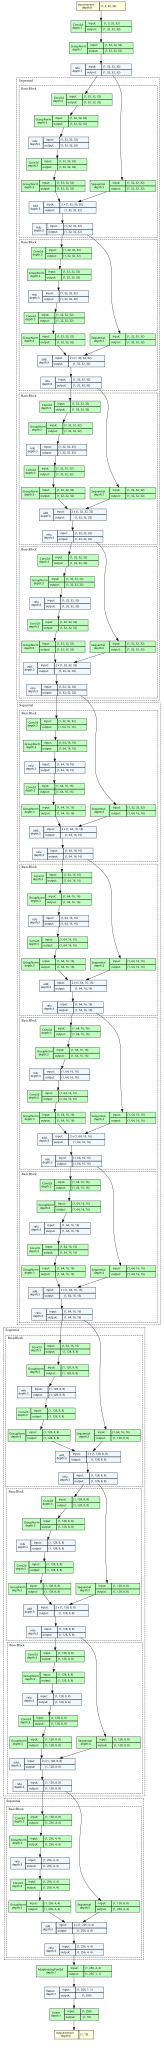

In [ ]:
#@title Printing model graph

model_graph = draw_graph(model, input_size=(1,3, 32, 32), expand_nested=True)
model_graph.visual_graph

In [ ]:
# Parameters

split_ratio = 0.9 # Ensure a 90-10 split for train and validate
root_dir = "/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py"
batch_size = 256
num_workers = 2  # Increase if CPU can support


num_epochs = 200
initial_lr = 0.1
use_amp = (device == "cuda")
label_smoothing = 0.1

In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict



def load_cifar10_batches(root_dir):
    data_list, labels_list = [], []
    for i in range(1, 6):
        batch_file = os.path.join(root_dir, f"data_batch_{i}")
        batch = unpickle(batch_file)
        data_list.append(batch[b'data'])
        labels_list.extend(batch[b'labels'])
    val_batch = unpickle('/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py/test_batch')
    X_val = val_batch[b'data']
    y_val = val_batch[b'labels']
    X = np.concatenate(data_list, axis=0)
    y = np.array(labels_list)
    return X, y, X_val, y_val




In [ ]:


def get_transforms(normalization=True, augmentation=True, jitter=False):
    train_transform_list = [] # Initialize as an empty list
    test_transform_list = []  # Initialize as an empty list
    train_transform_list.append(transforms.ToPILImage())
    test_transform_list.append(transforms.ToPILImage())
    if augmentation:
        train_transform_list.extend([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip()
        ])
    if jitter:
        train_transform_list.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1))



    train_transform_list.append(transforms.ToTensor())
    test_transform_list.append(transforms.ToTensor())

    if normalization:
        norm_transform = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        train_transform_list.append(norm_transform)
        test_transform_list.append(norm_transform)

    train_transforms = transforms.Compose(train_transform_list)
    test_transforms = transforms.Compose(test_transform_list)
    return train_transforms, test_transforms

#####################--------------------
#@title CIFAR Dataset

class CIFARDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data  # shape (N, 3072)
        self.labels = labels  # shape (N,)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Reshape vector (3072,) -> (32, 32, 3), then convert to PIL Image
        img = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype("uint8")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label



#####################--------------------

X_train, y_train, X_val, y_val = load_cifar10_batches(root_dir)
train_transforms, test_transforms = get_transforms()
train_dataset = CIFARDataset(X_train, y_train, transform=train_transforms)
val_dataset = CIFARDataset(X_val, y_val, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size*2,
    shuffle=False,  # Necessary for validation
    num_workers=num_workers,
)




#####################--------------------
# Objective function and LR
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

optimizer = optim.SGD(
    model.parameters(), lr=initial_lr, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.cuda.amp.GradScaler() if use_amp else None




#####################--------------------
#@title Early Stopping

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        Args:
        - patience (int): How many epochs to wait before stopping if no improvement.
        - min_delta (float): Minimum change in validation loss to be considered an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                return True
        return False

early_stopping = EarlyStopping(patience=10, min_delta=0.001)




############----------------------
#@title Train loop

best_val_acc = 0.0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        train_progress.set_postfix(loss=loss.item())

    scheduler.step()

    # Evalution after each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100.0 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/DL_Project_Data/Notebooks/checkpoints/best_model.pth")
        print(f"Saved new best model at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")

    if early_stopping(1 - val_acc):
        break  # Stop training early if no improvement

print("Training complete.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/200] - Loss: 2.3447 | Val Acc: 22.22%
Saved new best model at epoch 1 with Val Acc: 22.22%


Epoch [2/200] - Loss: 2.0628 | Val Acc: 26.27%
Saved new best model at epoch 2 with Val Acc: 26.27%


Epoch [3/200] - Loss: 1.9551 | Val Acc: 35.10%
Saved new best model at epoch 3 with Val Acc: 35.10%


Epoch [4/200] - Loss: 1.8336 | Val Acc: 39.53%
Saved new best model at epoch 4 with Val Acc: 39.53%


Epoch [5/200] - Loss: 1.7644 | Val Acc: 39.96%
Saved new best model at epoch 5 with Val Acc: 39.96%


...

Epoch [72/200] - Loss: 0.7389 | Val Acc: 83.62%


Epoch [73/200] - Loss: 0.7348 | Val Acc: 84.13%


Epoch [74/200] - Loss: 0.7251 | Val Acc: 86.72%


Epoch [75/200] - Loss: 0.7271 | Val Acc: 86.47%


Epoch [76/200] - Loss: 0.7240 | Val Acc: 86.25%
Early stopping triggered!
Training complete.
Best Validation Accuracy: 86.77%


In [ ]:
#@title Early Stopping

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        Args:
        - patience (int): How many epochs to wait before stopping if no improvement.
        - min_delta (float): Minimum change in validation loss to be considered an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                return True
        return False

early_stopping = EarlyStopping(patience=10, min_delta=0.001)




############----------------------
#@title Train loop

best_val_acc = 0.0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        train_progress.set_postfix(loss=loss.item())

    scheduler.step()

    # Evalution after each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100.0 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/DL_Project_Data/Notebooks/checkpoints/best_model.pth")
        print(f"Saved new best model at epoch {epoch+1} with Val Acc: {val_acc:.2f}%")

    if early_stopping(1 - val_acc):
        break  # Stop training early if no improvement

print("Training complete.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")